In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [ ]:
# import some basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataset = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ANN/ANN implementation/Churn_Modelling.csv")
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# divde datset in dependent and independent features
X = dataset.iloc[:, 3:13]
Y = dataset.iloc[:, 13]

In [ ]:
print(X)

      CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0             619    France  Female   42       2       0.00              1   
1             608     Spain  Female   41       1   83807.86              1   
2             502    France  Female   42       8  159660.80              3   
3             699    France  Female   39       1       0.00              2   
4             850     Spain  Female   43       2  125510.82              1   
...           ...       ...     ...  ...     ...        ...            ...   
9995          771    France    Male   39       5       0.00              2   
9996          516    France    Male   35      10   57369.61              1   
9997          709    France  Female   36       7       0.00              1   
9998          772   Germany    Male   42       3   75075.31              2   
9999          792    France  Female   28       4  130142.79              1   

      HasCrCard  IsActiveMember  EstimatedSalary  
0           

In [ ]:
print(Y)

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64


In [ ]:
# Feature Engineering
geography = pd.get_dummies(X['Geography'], drop_first=True)
gender = pd.get_dummies(X['Gender'], drop_first=True)

# we have geography and gender in our dataset, so we need to perform one hot encoding to convert categorical column into numerical column

In [ ]:
# Concatinate these new column with dataset
X = X.drop(['Geography', 'Gender'], axis= 1)

In [ ]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [ ]:
X = pd.concat([X, geography.astype(int), gender.astype(int)], axis = 1)

In [ ]:
print(X)

      CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0             619   42       2       0.00              1          1   
1             608   41       1   83807.86              1          0   
2             502   42       8  159660.80              3          1   
3             699   39       1       0.00              2          0   
4             850   43       2  125510.82              1          1   
...           ...  ...     ...        ...            ...        ...   
9995          771   39       5       0.00              2          1   
9996          516   35      10   57369.61              1          1   
9997          709   36       7       0.00              1          0   
9998          772   42       3   75075.31              2          1   
9999          792   28       4  130142.79              1          1   

      IsActiveMember  EstimatedSalary  Germany  Spain  Male  
0                  1        101348.88        0      0     0  
1                  1   

In [ ]:
X.shape

(10000, 11)

## Splitting dataset into training and testing

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state= 0)

## Feature Scaling on Training & Testing dataset

feature scaling are use to transfrom data in particular range so no feature(column) dominate

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [ ]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

# ANN part begins

In [ ]:
X_train.shape

(8000, 11)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import ReLU, LeakyReLU, ELU, PReLU
from tensorflow.keras.layers import Dropout

In [ ]:
#initialize the ANN
classifier = Sequential()

In [ ]:
# Adding input layer
classifier.add(Dense(units = 11, activation = 'relu'))

# becoz we have 11 input feature thats why we add 11 units


In [ ]:
# add hidden layers
classifier.add(Dense(units = 7, activation = 'relu'))

# add another hidden layer
classifier.add(Dense(units = 6, activation = 'relu'))

In [ ]:
# adding output layer
classifier.add(Dense(1, activation= 'sigmoid'))

# we want only one output neuron
# when there are more than two class we use softmax (multiclass-classification)
# when there is less than two class we use binary(means sigmoid ) (binary classification)

## Compile the model

In [ ]:
classifier.compile(optimizer = 'adam', loss ='binary_crossentropy', metrics = ['accuracy'])

# becoz it is binary classification problem, we use binary_crossentroy

# Train NN

In [ ]:
import tensorflow as tf
from tensorflow import keras
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

# Stop training when a monitored metric has stopped improving.

In [ ]:
model_history = classifier.fit(X_train, y_train,validation_split = 0.33,  batch_size= 10, epochs = 500, callbacks = early_stopping)
chs
# validation_split = 0.33 means that 33% of the training data is set aside as validation data during model training.”
# bacth_size = divide the dataset into smaller batches
# epochs = no. of time model pocess entire dataset

Epoch 1/500
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8643 - loss: 0.3306 - val_accuracy: 0.8504 - val_loss: 0.3629
Epoch 2/500
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8653 - loss: 0.3299 - val_accuracy: 0.8519 - val_loss: 0.3579
Epoch 3/500
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8647 - loss: 0.3289 - val_accuracy: 0.8489 - val_loss: 0.3590
Epoch 4/500
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8655 - loss: 0.3279 - val_accuracy: 0.8470 - val_loss: 0.3612
Epoch 5/500
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8643 - loss: 0.3273 - val_accuracy: 0.8519 - val_loss: 0.3584
Epoch 6/500
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8643 - loss: 0.3270 - val_accuracy: 0.8482 - val_loss: 0.3600
Epoch 7/500
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8651 - loss: 0.3261 - val_accuracy: 0.8546 - val_loss: 0.3559
Epoch 8/500
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8664 - loss: 0.3255 - val_accu

In [ ]:
model_history.history.keys()

# base on that keys model is evaluate

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

# plot the summary for history

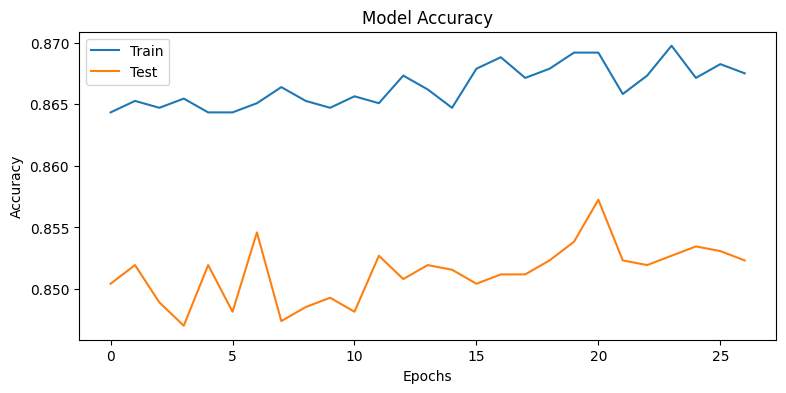

In [ ]:
# plot history summary for accuracy
plt.figure(figsize=(9,4))
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

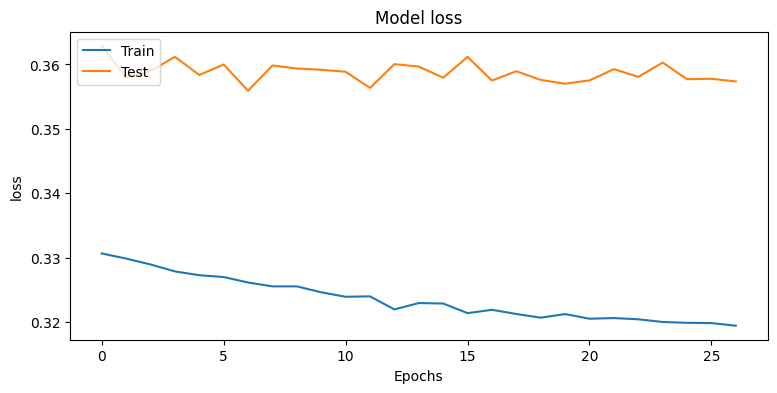

In [ ]:
# plot history summary for loss
plt.figure(figsize=(9,4))
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title("Model loss")
plt.xlabel("Epochs")
plt.ylabel('loss')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Prediction for Test Data

In [ ]:
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [ ]:
# make a confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1487,  108],
       [ 193,  212]])

In [ ]:
# calculate accuracy
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
score

0.8495

# Customer Bank Churn Prediction – Analytical Report

## 1. Overview

This notebook focuses on predicting customer churn (customer exit behavior) for a bank using an Artificial Neural Network (ANN) implemented with TensorFlow/Keras.

The overall workflow includes:

* Loading and preprocessing customer banking data
* Performing feature engineering on categorical variables
* Splitting the dataset into training and testing sets
* Scaling numerical features
* Building and training an ANN model
* Evaluating model performance using accuracy and confusion matrix
* Visualizing training and validation performance trends

The primary objective is to classify whether a bank customer is likely to exit (churn) or remain with the bank.

---

# 2. Problem Statement

## Inferred Problem

The notebook aims to solve a binary classification problem:

> Predict whether a customer will leave the bank based on demographic and banking-related attributes.

The target variable appears to be:

* `Exited`

  * `1` → Customer exited the bank
  * `0` → Customer stayed with the bank

##

---

# 3. Libraries Used

| Library                   | Purpose                                                    |
| ------------------------- | ---------------------------------------------------------- |
| `tensorflow`              | Deep learning framework used for ANN creation and training |
| `keras` (via TensorFlow)  | High-level API for neural network modeling                 |
| `numpy`                   | Numerical operations and array handling                    |
| `pandas`                  | Data loading and preprocessing                             |
| `matplotlib.pyplot`       | Visualization of model performance                         |
| `seaborn`                 | Statistical visualization support                          |
| `sklearn.model_selection` | Train-test data splitting                                  |
| `sklearn.preprocessing`   | Feature scaling using `StandardScaler`                     |
| `sklearn.metrics`         | Evaluation metrics such as confusion matrix and accuracy   |

---

# 4. Data Flow / Workflow

## Step 1: Import Required Libraries

Imported libraries for:

* Data handling
* Visualization
* Neural network implementation
* Model evaluation

---

## Step 2: Load Dataset

Loaded the bank customer churn dataset into a Pandas DataFrame for analysis and model training.

---

## Step 3: Select Features and Target Variable

Separated:

* Input features (customer details)
* Target variable (`Exited`)

---

## Step 4: Encode Categorical Variables

Converted categorical columns such as Geography and Gender into numerical format using encoding techniques.

---

## Step 5: Split Dataset

Divided the dataset into:

* Training set
* Testing set

This allows model training and performance evaluation on unseen data.

---

## Step 6: Feature Scaling

Applied standardization to normalize feature values before ANN training.

---

## Step 7: Build ANN Model

Created an Artificial Neural Network with:

* Input layer
* Multiple hidden layers
* Output layer for binary classification

---

## Step 8: Compile the Model

Configured:

* Optimizer
* Loss function
* Accuracy metric

for binary classification training.

---

## Step 9: Apply Early Stopping

Used early stopping to reduce overfitting by monitoring validation loss.

---

## Step 10: Train the Model

Trained the ANN using training data and validation split.

---

## Step 11: Visualize Performance

Generated:

* Accuracy graph
* Loss graph

to monitor training and validation performance.

---

## Step 12: Make Predictions

Predicted customer churn on the test dataset.

---

## Step 13: Evaluate Model Performance

Evaluated model performance using:

* Confusion matrix
* Accuracy score

---

# 5. Algorithms Used

## Artificial Neural Network (ANN)

The notebook uses a feedforward neural network for binary classification.

### Key Components

| Component           | Description                                    |
| ------------------- | ---------------------------------------------- |
| Dense Layers        | Fully connected neural network layers          |
| ReLU Activation     | Introduces non-linearity in hidden layers      |
| Sigmoid Activation  | Produces probability for binary classification |
| Adam Optimizer      | Adaptive gradient optimization algorithm       |
| Backpropagation     | Used internally for weight updates             |
| Binary Crossentropy | Loss function for binary classification        |

---

## One-Hot Encoding

Used for transforming categorical variables into numerical vectors.

---

## Standardization

Feature scaling using Z-score normalization:

---

# 6. Evaluation Metrics

## Accuracy

Measures the proportion of correct predictions.

###

---

## Confusion Matrix

A confusion matrix is generated to evaluate classification outcomes.

It helps identify:

* Correct predictions
* False alarms
* Missed churn cases

---

## Validation Loss Monitoring

Validation loss is monitored during training through early stopping.

This helps:

* Prevent overfitting
* Improve generalization
* Select better stopping point automatically

---

# 7. Results / Outputs

## Key Outputs Generated

The notebook produces:

* Processed feature matrix
* Scaled training and testing datasets
* ANN training history
* Accuracy and loss plots
* Predicted churn labels
* Confusion matrix
* Final accuracy score

---

## Training Performance Visualization

### Accuracy Curve

The accuracy plot demonstrates how:

* Training accuracy evolves across epochs
* Validation accuracy compares with training performance

Interpretation:

* Similar training and validation curves generally indicate stable learning.
* Large gaps may indicate overfitting.

---

## Loss Curve

The loss graph shows:

* Reduction of training loss over time
* Validation loss behavior

Interpretation:

* Decreasing loss suggests successful optimization.
* Increasing validation loss while training loss decreases may indicate overfitting.

---

## Prediction Results

The ANN predicts whether customers are likely to exit.

The binary outputs are obtained using a sigmoid threshold of 0.5.

---

## Confusion Matrix Interpretation

The confusion matrix helps analyze:

* Correct churn predictions
* Incorrect churn predictions
* Misclassification patterns

This is especially important for business use cases because false negatives may represent customers at risk who are not identified.

---

## Accuracy Score

The notebook computes overall classification accuracy.

However, the exact final accuracy value is not visible in the notebook snapshot provided.

---

###

# Conclusion

This notebook demonstrates an end-to-end ANN implementation for bank customer churn prediction using TensorFlow/Keras.

The workflow covers:

* Data preprocessing
* Feature engineering
* Feature scaling
* ANN model creation
* Model training
* Performance evaluation

The project provides a strong foundational implementation of deep learning for binary classification problems and serves as a practical introduction to neural networks in customer analytics and churn prediction domains.
